# Practical Session : Image segmentation

The objective of this practical session is to perform the segmentation of noisy images of disks using the Context Aggregation Network introduced by Yu and Koltun in 2015.

Yu, F., & Koltun, V. (2015). Multi-scale context aggregation by dilated convolutions. arXiv preprint arXiv:1511.07122.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from icecream import ic
import keras

I0000 00:00:1773144068.580026  314237 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773144068.605586  314237 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773144069.579300  314237 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773144077.662210  314237 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## 1. Data generation

The code below allows to simulate images of disks with distinct gray levels. The images are $64 \times 64$ pixels images encoded on 8 bites. An average of $\theta = 5$ disks are randomly generated in each image. The radii of the disks are sampled from independent normal distributions with mean $4$ pixels and standard deviation $0.5$ pixel. The gray level of each disk is drawn randomly from an uniform distribution between $15$ and $200$.
White noise with standard deviation $\sigma = 30$ pixels is then added to the images.

In [2]:
class Data_Generator:
    """
    Class used to generate synthetic images

    Attributes
    ----------

    """
    nx: int
    ny: int # nx*ny shape of the synthetic image
    theta: float # average number of disks per image
    rmean: float # average radius of the disks
    rstd: float # standard deviation of the radii
    vmin: int
    vmax: int # vmin & vmax minimal/maximal gray level of the disks
    sigma: float # standard deviation of the noise
    img: np.ndarray # synthetic image
    img_truth: np.ndarray # ground truth image
    ndisks: int # number of disks


    def __init__(self, size: int, theta: float, rmean: float, rstd: float, vmin: int, vmax: int, sigma: float):
        """
        Constructor

        """

        self.nx, self.ny = size
        self.theta = theta
        self.rmean, self.rstd = rmean, rstd
        self.vmin, self.vmax = vmin, vmax
        self.sigma = sigma

        self.img = np.zeros((self.nx, self.ny))
        self.img_truth = np.zeros((self.nx, self.ny))

    def generate(self):
        """
        Generate a synthetic image
        """

        x = np.linspace(0, self.nx - 1, self.nx)
        y = np.linspace(0, self.ny - 1, self.ny)
        xx, yy = np.meshgrid(x, y)

        self.ndisks = np.random.poisson(self.theta)

        for n in range(self.ndisks):

            xc = np.random.uniform(0, self.nx)
            yc = np.random.uniform(0, self.ny)
            r = np.random.normal(loc=self.rmean, scale=self.rstd)
            v = np.random.uniform(self.vmin, self.vmax)

            mask = np.power(xx - xc, 2) + np.power(yy - yc, 2) - r**2 < 0
            self.img[mask] = v
            self.img_truth[mask] = 1

        noise = self.sigma * np.random.randn(self.nx, self.ny)
        self.img = np.clip(self.img + noise, 0, 255)
        return self.img, self.img_truth

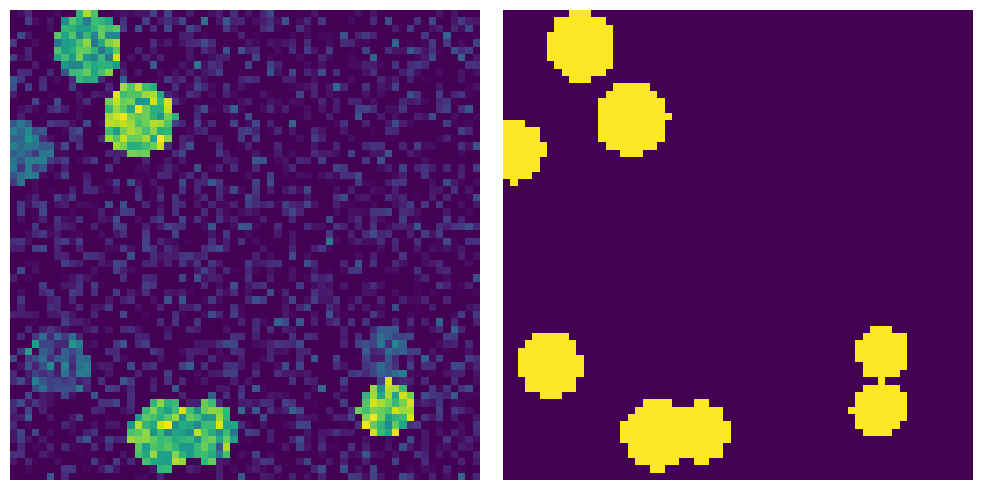

In [3]:
img_rows, img_cols, img_channels = 64, 64, 1
size = (img_rows, img_cols)
theta = 5
rmean = 4
rstd = 0.5
vmin = 15
vmax = 200
sigma = 30

# Image generation
synthetic_img = Data_Generator(size, theta, rmean, rstd, vmin, vmax, sigma)
img, img_truth = synthetic_img.generate()

# Display the generated images
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].imshow(img)
ax[1].imshow(img_truth)
for a in ax.ravel():
    a.set_axis_off()
plt.tight_layout()
plt.show()

*Question 1*. Use the code of the previous cell to generate a dataset of 2000 training image and 200 validation images. The dataset must be at a format compatible with keras (ex: numpy array)

In [4]:
nb_training_samples = 2000
training_img, training_img_true = np.zeros((nb_training_samples, 64, 64)), np.zeros((nb_training_samples, 64, 64))

for i in range(nb_training_samples):
    synthetic_img = Data_Generator(size, theta, rmean, rstd, vmin, vmax, sigma)
    image, image_true = synthetic_img.generate()
    training_img[i] = image
    training_img_true[i] = image_true
ic(training_img.shape, training_img_true.shape)



ic| training_img.shape: (2000, 64, 64)
    training_img_true.shape: (2000, 64, 64)


((2000, 64, 64), (2000, 64, 64))

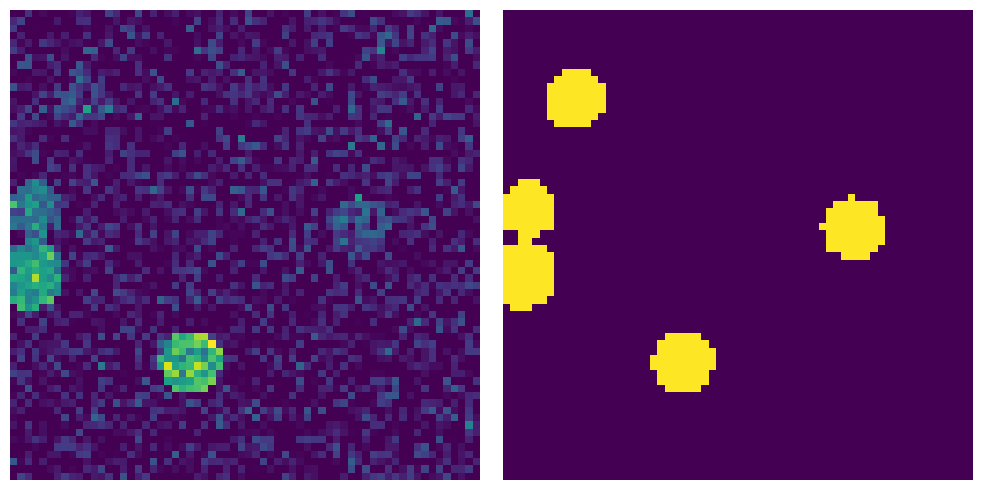

In [18]:
i=22
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].imshow(training_img[i])
ax[1].imshow(training_img_true[i])
for a in ax.ravel():
    a.set_axis_off()
plt.tight_layout()
plt.show()

In [8]:
nb_validation_samples = 200
validation_img, validation_img_true = np.zeros((nb_validation_samples, 64, 64)), np.zeros((nb_validation_samples, 64, 64))

for i in range(nb_validation_samples):
    synthetic_img = Data_Generator(size, theta, rmean, rstd, vmin, vmax, sigma)
    image, image_true = synthetic_img.generate()
    validation_img[i] = image
    validation_img_true[i] = image_true


## 2. Network Architecture

We use the Context Aggregation Network to perform the image segmentation. The particularity of this convolutional neural network is that it gradually aggregates contextual information without losing resolution through the use of dilated convolutions, whose field of view increases exponentially over the network layers. 

The input image is normalized and goes through a set of layers $\{L^1, \cdots, L^d\}$. The output of the network is constituted of an image with one channel corresponding to the segmentation mask for the disks.

Each block $L^s$, $s\in [\![2,d-1]\!]$ is made of 
1. a dilated convolution, with receptive field $ 3\times 3 $, depth $24$, dilation parameter $r_s=2^s$ and stride $1$, 
2. a batch normalization layer
3. a leaky rectifier linear unit (LReLU), defined as
$ \Phi(x) = \max(0.2 x, x) $
as activation function. 
Padding is applied to ensure that the output of the block has the same size as the input.

The final block of the network is composed of a 2D convolution with receptive field $1 \times 1$, depth $1$, stride $1$, dilation $1$ and uses a Sigmoid activation function.

*Question 2.* Implement the CAN architecture with Keras. Do not forget to include the normalization!

In [9]:
import keras
from keras import backend as K
from keras.models import Model
from keras.layers import Input, Conv2D, BatchNormalization, LeakyReLU


def make_model(input_shape, nb_modules):
    """
    Creates the network architecture

    Parameters
    ----------

    input shape: tuple of ints
        shape of the input image
    nb_modules: int
        number of module

    Returns
    -------

    out: Keras model
        Keras model for the CAN architecture
    """

    inputs = keras.layers.Input(shape=input_shape)
    layer = keras.layers.Rescaling(1.0 / 255)(inputs)
    for module in range(nb_modules):
        layer = keras.layers.Conv2D(filters=24,
                                    kernel_size=3,
                                    strides=1,
                                    dilation_rate=pow(2, module),
                                    padding="same")(layer)
        layer = keras.layers.BatchNormalization()(layer)
        layer = keras.layers.LeakyReLU(negative_slope=0.2)(layer)
    layer = keras.layers.Conv2D(filters=1, kernel_size=1, strides=1, dilation_rate=1, padding="same")(layer)
    layer_output = keras.activations.sigmoid(layer)

    return keras.models.Model(inputs, layer_output)

input_shape = (64, 64, 1)
nb_layers = 6
model = make_model(input_shape, nb_layers)
model.compile(optimizer="rmsprop", loss="mse")
model.summary()

E0000 00:00:1773144134.943197  314237 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 24)     │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64, 64, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 64, 64, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64, 64, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 64, 64, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 64, 64, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 1)      │            25 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sigmoid (Sigmoid)               │ (None, 64, 64, 1)      │             

 Total params: 26,881 (105.00 KB)

 Trainable params: 26,593 (103.88 KB)

 Non-trainable params: 288 (1.12 KB)

## 3. Train the model

The code in the following cell trains the neural network architecture and plot the evolution of the training loss/validation loss according to the epochs.

In [10]:
# training
history = model.fit(
    training_img,
    training_img_true,
    batch_size=32,
    epochs=10,
    validation_data=(validation_img, validation_img_true),
    verbose=True,
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - loss: 0.1262 - val_loss: 0.1514
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - loss: 0.0304 - val_loss: 0.0704
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - loss: 0.0121 - val_loss: 0.0366
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - loss: 0.0073 - val_loss: 0.0256
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 276s 4s/step - loss: 0.0060 - val_loss: 0.0198
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - loss: 0.0056 - val_loss: 0.0146
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 386s 6s/step - loss: 0.0054 - val_loss: 0.0070
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - loss: 0.0052 - val_loss: 0.0068
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - loss: 0.0051 - val_loss: 0.0103
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - loss: 0.0050 - val_loss: 0.0053


In [11]:
# **** #####################################"
print("Best validation loss: %.5f" % (np.min(history.history["val_loss"])))
print("at: %d" % np.argmin(history.history["val_loss"]))

Best validation loss: 0.00533
at: 9


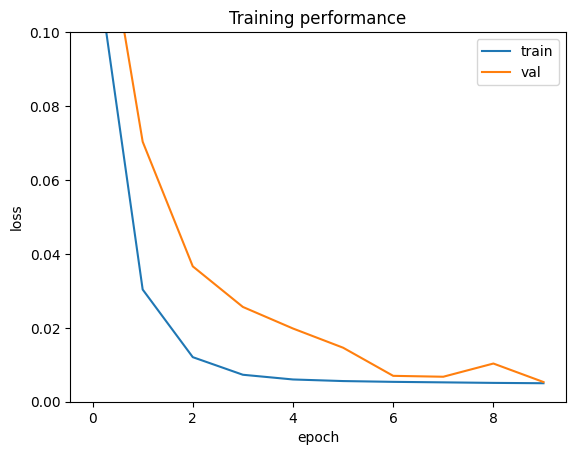

In [12]:
plt.plot(history.epoch, history.history["loss"], label="train")
plt.plot(history.epoch, history.history["val_loss"], label="val")
plt.title("Training performance")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend()
plt.ylim(0.0, 0.1)
plt.show()

## 4: Test the model

*Question 3*. Generate a dataset of 10 test images and test the result of the algorithm on these images.


In [19]:
nb_testing_samples = 10

testing_img, testing_img_true = np.zeros((nb_testing_samples, 64, 64)), np.zeros((nb_testing_samples, 64, 64))

for i in range(nb_testing_samples):
    synthetic_img = Data_Generator(size, theta, rmean, rstd, vmin, vmax, sigma)
    image, image_true = synthetic_img.generate()
    testing_img[i] = image
    testing_img_true[i] = image_true

ic(testing_img.shape)


print("Generation of the test set completed")

Generation of the test set completed


ic| testing_img.shape: (10, 64, 64)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step


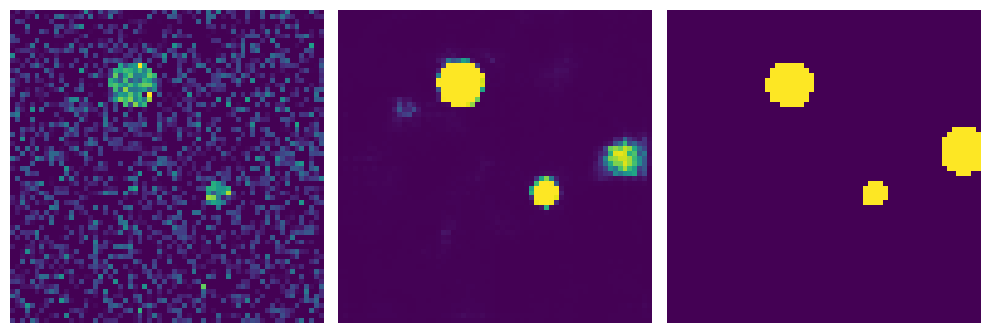

In [22]:
index = 2
fig, ax = plt.subplots(1, 3, figsize=(10, 5), sharex=True, sharey=True)
ax[0].imshow(testing_img[index, :, :])
ax[1].imshow(model.predict(np.array([testing_img[index, :, :]]))[0, :, :, 0])
ax[2].imshow(testing_img_true[index, :, :])
for a in ax.ravel():
    a.set_axis_off()
plt.tight_layout()
plt.show()